# Etapa 3: Análise Exploratória e Consultas SQL

## 3.1 Objetivo

Compreender os dados através de análises estatísticas aprofundadas e consultas SQL avançadas que respondam às perguntas de pesquisa, garantindo que os dados estejam em formato adequado para análise e modelagem.

## Estrutura deste Notebook

1. **Configuração e Carregamento de Dados**: Importar bibliotecas e carregar o dataset limpo.
2. **Preparação em Formato Tidy e Exportação**: Garantir a organização dos dados e exportar para Parquet.
3. **Consultas SQL Analíticas Avançadas**: 5+ consultas com CTEs, funções de janela e agregações complexas.
4. **Análise Exploratória de Dados (EDA)**:
   - Análise Univariada
   - Análise Bivariada
   - Análise Multivariada
5. **Teste de Hipóteses**: Validação estatística das observações.
6. **Conclusões e Insights**: Sumarizar os achados para a etapa de modelagem.


## 1. Configuração e Carregamento


In [3]:
# Importação de bibliotecas essenciais
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings

try:
    import pyarrow
except ImportError:
    import pyarrow

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✓ Bibliotecas importadas e configuradas com sucesso")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Bibliotecas importadas e configuradas com sucesso
Timestamp: 2025-11-30 19:24:24


In [4]:
# Carregamento do dataset limpo
cleaned_csv_path = '/home/exati/trab_final/creditcard_cleaned.csv'
df_clean = pd.read_csv(cleaned_csv_path)

print("="*80)
print("CARREGAMENTO DO DATASET LIMPO")
print("="*80)
print(f"Dimensões do dataset: {df_clean.shape}")
print(f"Memória utilizada: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nPrimeiras 5 linhas:")
print(df_clean.head())

CARREGAMENTO DO DATASET LIMPO
Dimensões do dataset: (283726, 34)
Memória utilizada: 90.19 MB

Primeiras 5 linhas:
    Time      V1      V2     V3      V4      V5      V6      V7      V8  \
0 0.0000 -1.3598 -0.0728 2.5363  1.3782 -0.3383  0.4624  0.2396  0.0987   
1 0.0000  1.1919  0.2662 0.1665  0.4482  0.0600 -0.0824 -0.0788  0.0851   
2 1.0000 -1.3584 -1.3402 1.7732  0.3798 -0.5032  1.8005  0.7915  0.2477   
3 1.0000 -0.9663 -0.1852 1.7930 -0.8633 -0.0103  1.2472  0.2376  0.3774   
4 2.0000 -1.1582  0.8777 1.5487  0.4030 -0.4072  0.0959  0.5929 -0.2705   

       V9     V10     V11     V12     V13     V14     V15     V16     V17  \
0  0.3638  0.0908 -0.5516 -0.6178 -0.9914 -0.3112  1.4682 -0.4704  0.2080   
1 -0.2554 -0.1670  1.6127  1.0652  0.4891 -0.1438  0.6356  0.4639 -0.1148   
2 -1.5147  0.2076  0.6245  0.0661  0.7173 -0.1659  2.3459 -2.8901  1.1100   
3 -1.3870 -0.0550 -0.2265  0.1782  0.5078 -0.2879 -0.6314 -1.0596 -0.6841   
4  0.8177  0.7531 -0.8228  0.5382  1.3459 -1.1197 

## 2. Preparação dos Dados em Formato Tidy e Exportação

### 2.1 Organização dos Dados

O dataset já se encontra em formato _tidy_:

- **Cada variável é uma coluna**: `Time`, `Amount`, `V1-V28`, `Class`, etc.
- **Cada observação é uma linha**: Cada linha representa uma transação única.
- **Cada tipo de unidade observacional forma uma tabela**: A tabela `transactions_clean` representa um único tipo de entidade (transações).

### 2.2 Exportação para Formato Parquet

O formato Parquet é otimizado para performance e armazenamento, sendo ideal para pipelines de dados.


In [5]:
# Exportar para Parquet
parquet_path = '/home/exati/trab_final/creditcard_cleaned.parquet'
df_clean.to_parquet(parquet_path, engine='pyarrow')

print("="*80)
print("EXPORTAÇÃO PARA PARQUET")
print("="*80)
print(f"✓ Dataset limpo salvo com sucesso em formato Parquet:")
print(f"  - Local: {parquet_path}")

# Verificação do tamanho
import os
parquet_size = os.path.getsize(parquet_path) / 1024**2
csv_size = os.path.getsize(cleaned_csv_path) / 1024**2
print(f"  - Tamanho do Parquet: {parquet_size:.2f} MB")
print(f"  - Tamanho do CSV: {csv_size:.2f} MB")
print(f"  - Redução de espaço: {(1 - parquet_size / csv_size) * 100:.2f}%")

EXPORTAÇÃO PARA PARQUET
✓ Dataset limpo salvo com sucesso em formato Parquet:
  - Local: /home/exati/trab_final/creditcard_cleaned.parquet
  - Tamanho do Parquet: 69.70 MB
  - Tamanho do CSV: 147.47 MB
  - Redução de espaço: 52.74%


## 3. Consultas SQL Analíticas Avançadas

Conectando ao banco de dados SQLite criado na etapa anterior para executar consultas complexas.


In [6]:
# Conexão com o banco de dados SQLite
db_path = '/home/exati/trab_final/creditcard.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print(f"✓ Conectado ao banco de dados: {db_path}")

✓ Conectado ao banco de dados: /home/exati/trab_final/creditcard.db


### Consulta 1: Análise de Tendência com Média Móvel (Função de Janela)

**Objetivo**: Identificar tendências na taxa de fraude ao longo do tempo, suavizando flutuações diárias com uma média móvel de 3 dias.


CONSULTA 1: TENDÊNCIA DE FRAUDE COM MÉDIA MÓVEL
     Day  Taxa_Fraude_Pct  Media_Movel_3D
0 0.0000           0.1886          0.1886
1 1.0000           0.1441          0.1663


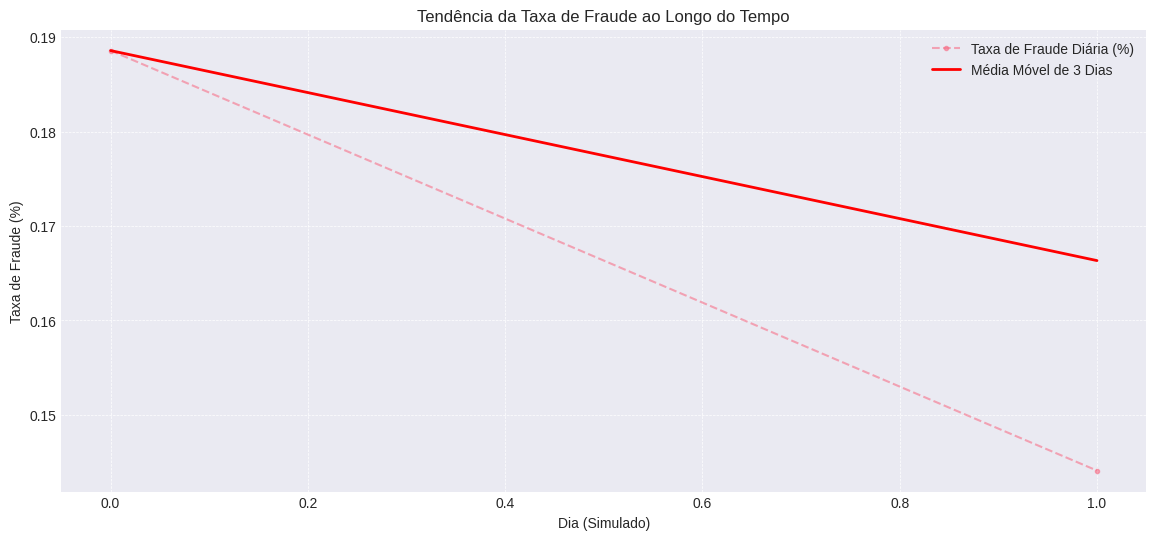

In [7]:
query1 = """
WITH DailyStats AS (
    -- Calcula estatísticas diárias de transações e fraudes
    SELECT
        Day,
        COUNT(*) as Total_Transacoes,
        SUM(CAST(Class AS INTEGER)) as Total_Fraudes
    FROM transactions_clean
    GROUP BY Day
),
FraudRate AS (
    -- Calcula a taxa de fraude diária
    SELECT
        Day,
        Total_Transacoes,
        Total_Fraudes,
        (Total_Fraudes * 100.0 / Total_Transacoes) as Taxa_Fraude_Pct
    FROM DailyStats
)
-- Calcula a média móvel de 3 dias da taxa de fraude
SELECT
    Day,
    Taxa_Fraude_Pct,
    AVG(Taxa_Fraude_Pct) OVER (ORDER BY Day ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as Media_Movel_3D
FROM FraudRate
ORDER BY Day;
"""

result1 = pd.read_sql_query(query1, conn)
print("="*80)
print("CONSULTA 1: TENDÊNCIA DE FRAUDE COM MÉDIA MÓVEL")
print("="*80)
print(result1)

# Visualização
plt.figure(figsize=(14, 6))
plt.plot(result1['Day'], result1['Taxa_Fraude_Pct'], label='Taxa de Fraude Diária (%)', marker='.', linestyle='--', alpha=0.6)
plt.plot(result1['Day'], result1['Media_Movel_3D'], label='Média Móvel de 3 Dias', color='red', linewidth=2)
plt.title('Tendência da Taxa de Fraude ao Longo do Tempo')
plt.xlabel('Dia (Simulado)')
plt.ylabel('Taxa de Fraude (%)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### Consulta 2: Análise de Concentração de Fraudes por Faixa de Valor (CTE)

**Objetivo**: Investigar se as fraudes se concentram em faixas de valor específicas, comparando a distribuição com transações legítimas.


CONSULTA 2: CONCENTRAÇÃO DE FRAUDES POR FAIXA DE VALOR
  Faixa_Valor  Legitimas  Fraudes   Total  Taxa_Fraude_Pct
0           0       1783       25    1808           1.3800
1         0-1      28377      146   28523           0.5100
2        1-50     159695      122  159817           0.0800
3      50-100      37124       55   37179           0.1500
4     100-500      47199       91   47290           0.1900
5        >500       9075       34    9109           0.3700


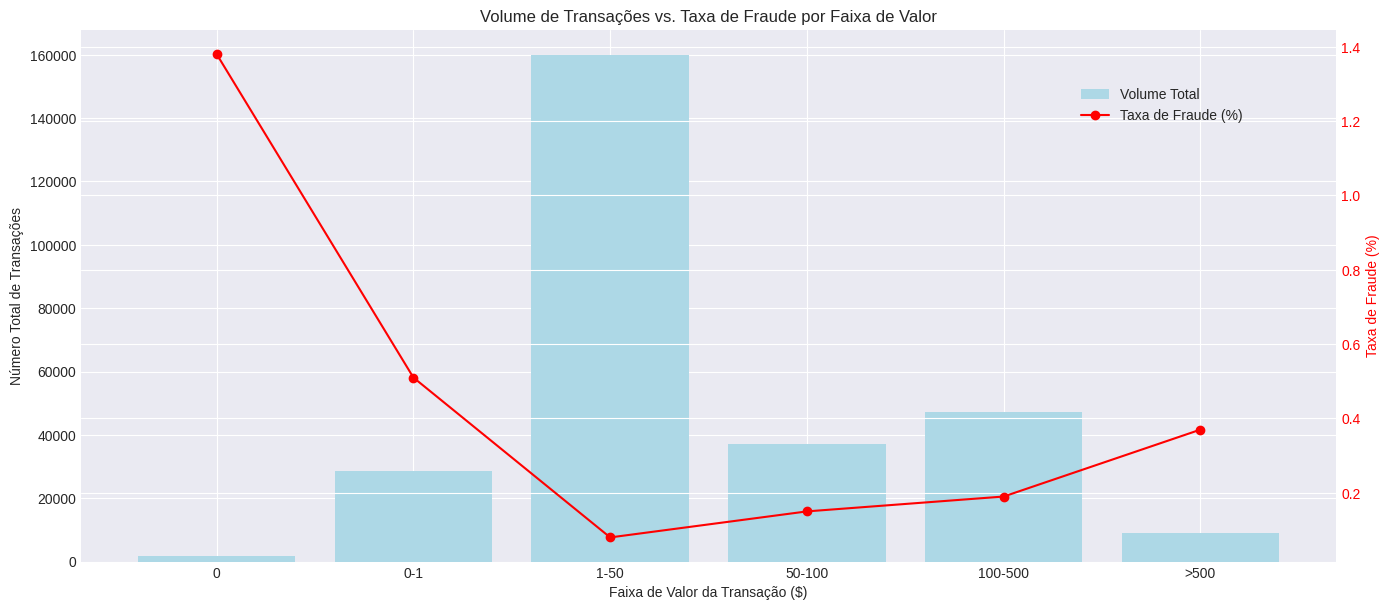

In [8]:
query2 = """
WITH AmountBins AS (
    -- Define faixas de valor para as transações
    SELECT
        CASE
            WHEN Amount = 0 THEN '0'
            WHEN Amount > 0 AND Amount <= 1 THEN '0-1'
            WHEN Amount > 1 AND Amount <= 50 THEN '1-50'
            WHEN Amount > 50 AND Amount <= 100 THEN '50-100'
            WHEN Amount > 100 AND Amount <= 500 THEN '100-500'
            ELSE '>500'
        END as Faixa_Valor,
        Class
    FROM transactions_clean
)
-- Agrega o número de fraudes e transações legítimas por faixa
SELECT
    Faixa_Valor,
    SUM(CASE WHEN Class = 0 THEN 1 ELSE 0 END) as Legitimas,
    SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) as Fraudes,
    COUNT(*) as Total,
    ROUND(SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Taxa_Fraude_Pct
FROM AmountBins
GROUP BY Faixa_Valor
ORDER BY
    CASE Faixa_Valor
        WHEN '0' THEN 0
        WHEN '0-1' THEN 1
        WHEN '1-50' THEN 2
        WHEN '50-100' THEN 3
        WHEN '100-500' THEN 4
        ELSE 5
    END;
"""

result2 = pd.read_sql_query(query2, conn)
print("="*80)
print("CONSULTA 2: CONCENTRAÇÃO DE FRAUDES POR FAIXA DE VALOR")
print("="*80)
print(result2)

# Visualização
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(result2['Faixa_Valor'], result2['Total'], color='lightblue', label='Volume Total')
ax1.set_xlabel('Faixa de Valor da Transação ($)')
ax1.set_ylabel('Número Total de Transações')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(result2['Faixa_Valor'], result2['Taxa_Fraude_Pct'], color='red', marker='o', label='Taxa de Fraude (%)')
ax2.set_ylabel('Taxa de Fraude (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()
plt.title('Volume de Transações vs. Taxa de Fraude por Faixa de Valor')
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.9))
plt.show()

### Consulta 3: Ranking de Horas com Maior Risco de Fraude (CTE e Ranking)

**Objetivo**: Classificar as horas do dia com base na taxa de fraude para identificar os períodos de maior risco.


In [9]:
query3 = """
WITH HourlyFraud AS (
    -- Calcula a taxa de fraude por hora
    SELECT
        Hour,
        COUNT(*) as Total_Transacoes,
        SUM(CAST(Class AS INTEGER)) as Total_Fraudes,
        (SUM(CAST(Class AS INTEGER)) * 100.0 / COUNT(*)) as Taxa_Fraude_Pct
    FROM transactions_clean
    GROUP BY Hour
)
-- Rankeia as horas pela taxa de fraude
SELECT
    Hour,
    Total_Transacoes,
    Total_Fraudes,
    ROUND(Taxa_Fraude_Pct, 2) as Taxa_Fraude_Pct,
    RANK() OVER (ORDER BY Taxa_Fraude_Pct DESC) as Ranking_Risco
FROM HourlyFraud
ORDER BY Ranking_Risco;
"""

result3 = pd.read_sql_query(query3, conn)
print("="*80)
print("CONSULTA 3: RANKING DE HORAS POR RISCO DE FRAUDE")
print("="*80)
print(result3)

CONSULTA 3: RANKING DE HORAS POR RISCO DE FRAUDE
      Hour  Total_Transacoes  Total_Fraudes  Taxa_Fraude_Pct  Ranking_Risco
0   2.0000              3308             48           1.4500              1
1   4.0000              2204             23           1.0400              2
2   3.0000              3487             17           0.4900              3
3   5.0000              2988             11           0.3700              4
4   7.0000              7233             23           0.3200              5
5  11.0000             16781             53           0.3200              6
6   1.0000              4208             10           0.2400              7
7   6.0000              4082              9           0.2200              8
8  17.0000             16130             28           0.1700              9
9  18.0000             16959             28           0.1700             10
10 15.0000             16374             26           0.1600             11
11 23.0000             10883           

### Consulta 4: Análise Comparativa de Features PCA (V1-V28) entre Classes

**Objetivo**: Comparar os valores médios das features `V` para transações fraudulentas e legítimas, identificando as features mais discriminativas.


CONSULTA 4: MÉDIA DAS FEATURES PCA (V1-V28) POR CLASSE
Classe     Legítima  Fraude
V1_Media     0.0134 -4.4983
V2_Media    -0.0098  3.4060
V3_Media     0.0129 -6.7296
V4_Media    -0.0104  4.4726
V5_Media     0.0068 -2.9572
V6_Media     0.0013 -1.4325
V7_Media     0.0104 -5.1759
V8_Media    -0.0024  0.9533
V9_Media     0.0026 -2.5221
V10_Media    0.0077 -5.4533
V11_Media   -0.0060  3.7163
V12_Media    0.0095 -6.1033
V13_Media    0.0008 -0.0943
V14_Media    0.0117 -6.8359
V15_Media    0.0012 -0.0728
V16_Media    0.0078 -4.0010
V17_Media    0.0110 -6.4633
V18_Media    0.0051 -2.1571
V19_Media   -0.0014  0.6691
V20_Media   -0.0005  0.4050
V21_Media   -0.0012  0.4666
V22_Media   -0.0002  0.0866
V23_Media    0.0004 -0.0965
V24_Media    0.0004 -0.1066
V25_Media   -0.0003  0.0406
V26_Media    0.0001  0.0505
V27_Media    0.0014  0.2138
V28_Media    0.0004  0.0783


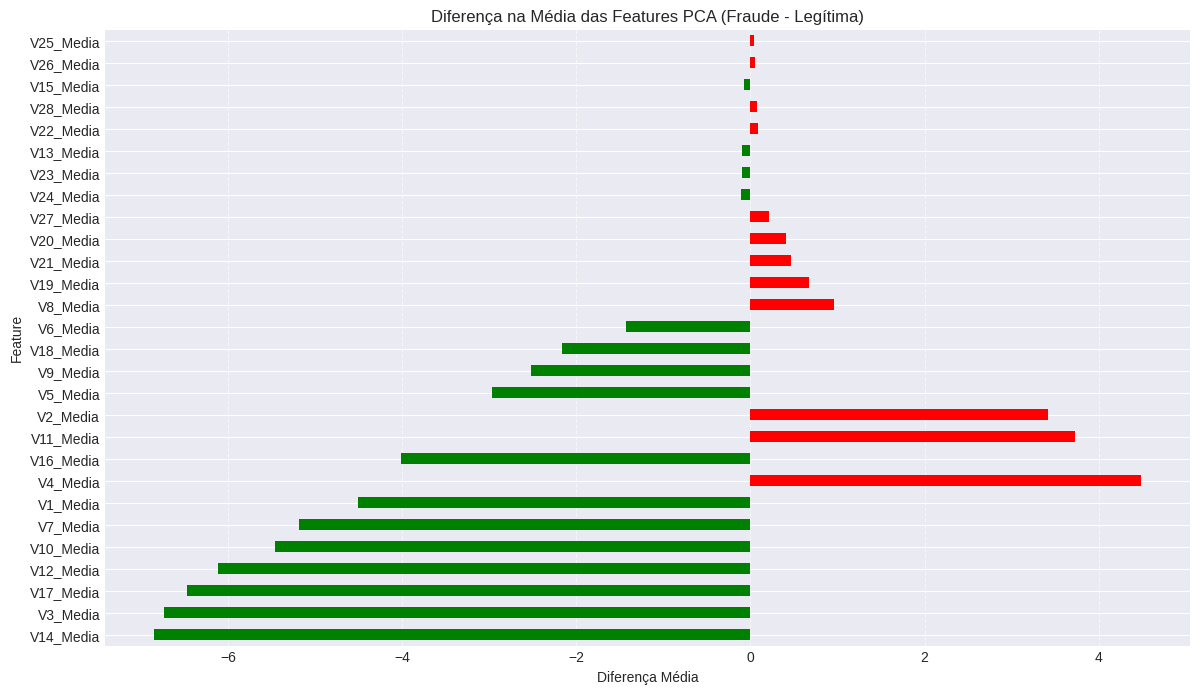

In [10]:
# Construção da query dinamicamente para analisar V1-V28
v_features_avg = ", ".join([f"ROUND(AVG(V{i}), 4) as V{i}_Media" for i in range(1, 29)])

query4 = f"""
SELECT
    CASE WHEN Class = 0 THEN 'Legítima' ELSE 'Fraude' END as Classe,
    {v_features_avg}
FROM transactions_clean
GROUP BY Class;
"""

result4 = pd.read_sql_query(query4, conn)
print("="*80)
print("CONSULTA 4: MÉDIA DAS FEATURES PCA (V1-V28) POR CLASSE")
print("="*80)
# Transpor para melhor visualização
result4_transposed = result4.set_index('Classe').T
print(result4_transposed)

# Visualização das diferenças
diffs = result4_transposed['Fraude'] - result4_transposed['Legítima']
diffs_sorted = diffs.abs().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
diffs.loc[diffs_sorted.index].plot(kind='barh', color=np.where(diffs.loc[diffs_sorted.index] > 0, 'red', 'green'))
plt.title('Diferença na Média das Features PCA (Fraude - Legítima)')
plt.xlabel('Diferença Média')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Consulta 5: Detecção de Anomalias Sequenciais (Função de Janela `LAG`)

**Objetivo**: Identificar transações que ocorrem muito próximas no tempo (delta de tempo pequeno), o que pode ser um sinal de atividade fraudulenta.


In [11]:
query5 = """
WITH TransactionTime AS (
    -- Calcula o tempo desde a transação anterior
    SELECT
        Time,
        Amount,
        Class,
        (Time - LAG(Time, 1, 0) OVER (ORDER BY Time)) as Delta_T_Anterior
    FROM transactions_clean
)
-- Filtra transações com delta de tempo muito curto e analisa a fraude
SELECT
    CASE
        WHEN Delta_T_Anterior <= 2 THEN 'Delta <= 2s'
        ELSE 'Delta > 2s'
    END as Intervalo_Temporal,
    COUNT(*) as Total_Transacoes,
    SUM(CAST(Class AS INTEGER)) as Total_Fraudes,
    ROUND(SUM(CAST(Class AS INTEGER)) * 100.0 / COUNT(*), 2) as Taxa_Fraude_Pct
FROM TransactionTime
WHERE Delta_T_Anterior > 0 -- Ignora a primeira transação
GROUP BY Intervalo_Temporal;
"""

result5 = pd.read_sql_query(query5, conn)
print("="*80)
print("CONSULTA 5: ANÁLISE DE FRAUDE POR INTERVALO ENTRE TRANSAÇÕES")
print("="*80)
print(result5)

CONSULTA 5: ANÁLISE DE FRAUDE POR INTERVALO ENTRE TRANSAÇÕES
  Intervalo_Temporal  Total_Transacoes  Total_Fraudes  Taxa_Fraude_Pct
0        Delta <= 2s            115679            187           0.1600
1         Delta > 2s              8912             57           0.6400


## 4. Análise Exploratória e Teste de Hipóteses

### 4.1 Análise Univariada

Análise da distribuição de variáveis individuais.


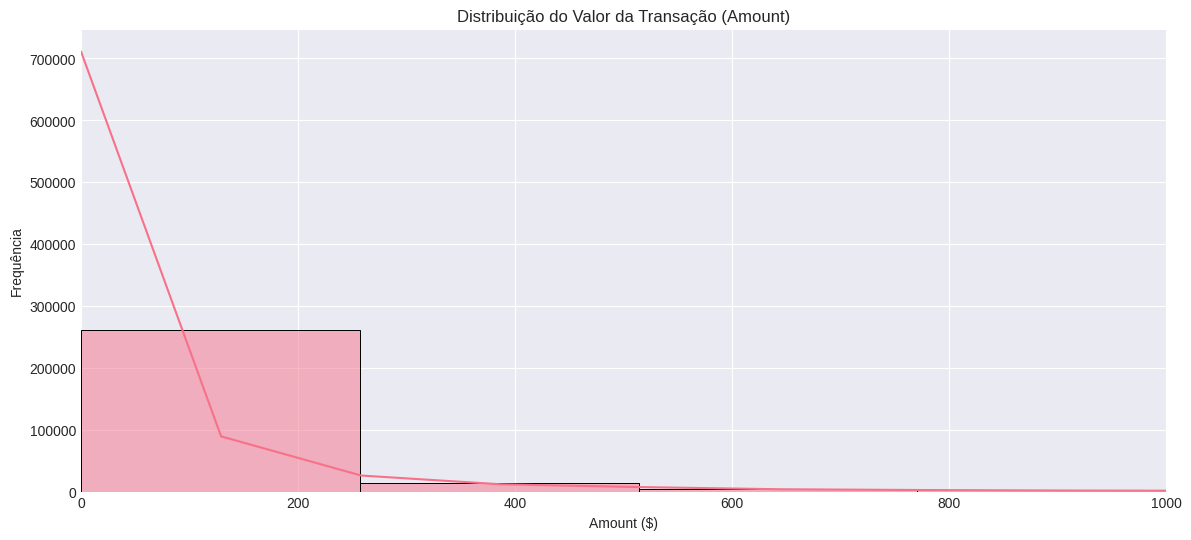

Estatísticas Descritivas de 'Amount':
count   283726.0000
mean        88.4727
std        250.3994
min          0.0000
25%          5.6000
50%         22.0000
75%         77.5100
max      25691.1600
Name: Amount, dtype: float64


In [12]:
# Análise da variável 'Amount'
plt.figure(figsize=(14, 6))
sns.histplot(df_clean['Amount'], bins=100, kde=True)
plt.title('Distribuição do Valor da Transação (Amount)')
plt.xlabel('Amount ($)')
plt.ylabel('Frequência')
plt.xlim(0, 1000) # Limita o eixo x para melhor visualização
plt.show()

print("Estatísticas Descritivas de 'Amount':")
print(df_clean['Amount'].describe())

### 4.2 Análise Bivariada

Análise da relação entre duas variáveis.


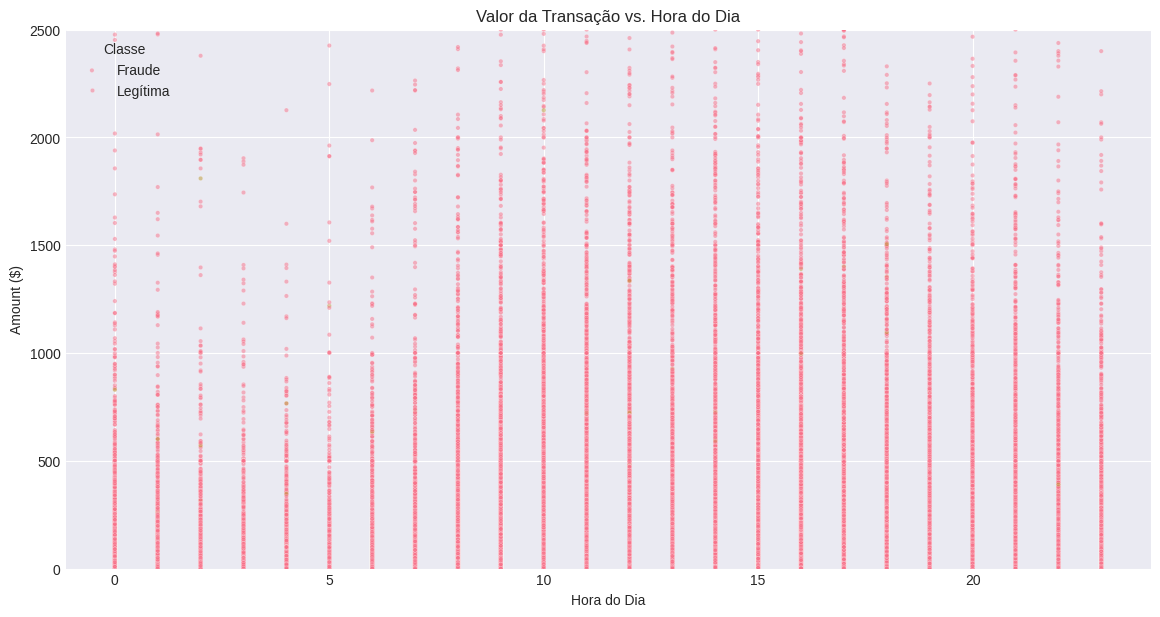

In [13]:
# Relação entre 'Time' (convertido para Hora) e 'Amount'
plt.figure(figsize=(14, 7))
sns.scatterplot(x='Hour', y='Amount', data=df_clean, hue='Class', alpha=0.5, s=10)
plt.title('Valor da Transação vs. Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Amount ($)')
plt.ylim(0, 2500) # Limita o eixo y
plt.legend(title='Classe', labels=['Fraude', 'Legítima'])
plt.show()

### 4.3 Análise Multivariada

Análise da correlação entre as principais features.


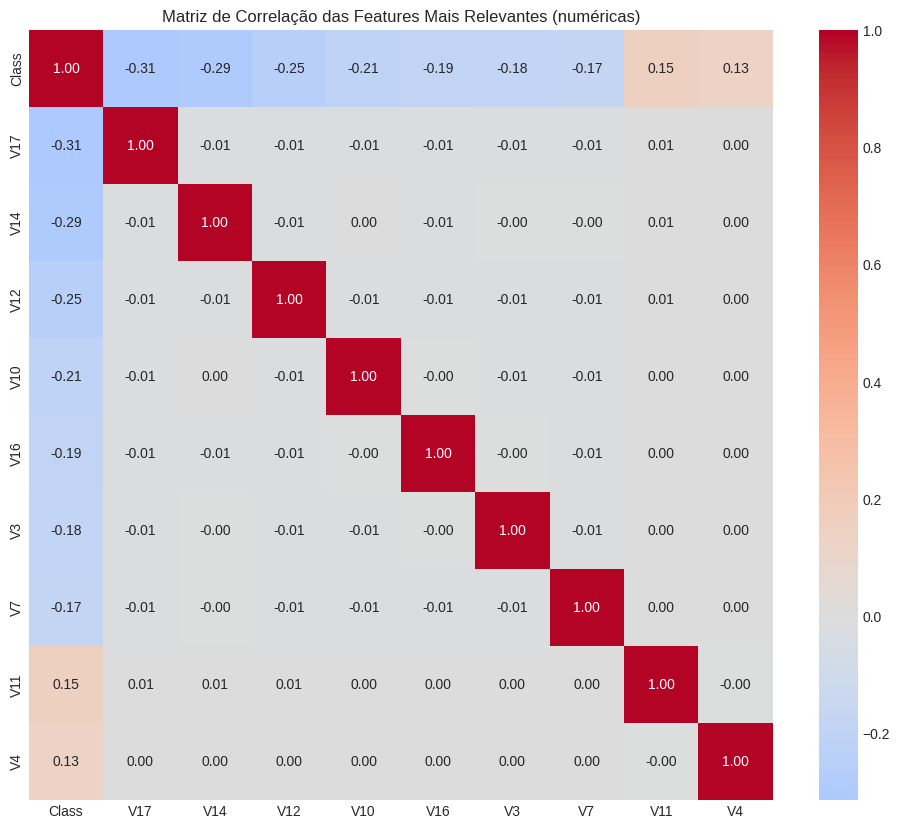

In [15]:
# Matriz de correlação com as features mais correlacionadas com 'Class'
# Ensure we only use numeric columns for correlation (categorical columns like TimeOfDay will break .corr())
numeric_df = df_clean.select_dtypes(include=[np.number]).copy()
# If 'Class' is not numeric (unlikely), coerce it to int
if 'Class' not in numeric_df.columns and 'Class' in df_clean.columns:
    numeric_df['Class'] = df_clean['Class'].astype(int)
# Compute correlation matrix on numeric columns
corr = numeric_df.corr()
# Select top 10 features most correlated with Class (by absolute correlation)
top_corr_features = corr['Class'].abs().nlargest(10).index.tolist()
# Build correlation map from the numeric subset using only the selected features
corr_map = numeric_df[top_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_map, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Matriz de Correlação das Features Mais Relevantes (numéricas)')
plt.show()

### 4.4 Teste de Hipóteses

**Hipótese**: O valor médio das transações fraudulentas é significativamente diferente do valor médio das transações legítimas.

- **H0 (Hipótese Nula)**: A média de `Amount` para `Class = 1` é igual à média de `Amount` para `Class = 0`.
- **H1 (Hipótese Alternativa)**: As médias são diferentes.

Usaremos o **Teste t de Welch**, que não assume variâncias iguais entre os grupos.


TESTE DE HIPÓTESE: VALOR MÉDIO DE TRANSAÇÕES (AMOUNT)
Média de Amount (Fraude): $123.87
Média de Amount (Legítima): $88.41
--------------------------------------------------------------------------------
Estatística t: 2.9613
Valor-p (p-value): 0.0032
--------------------------------------------------------------------------------
Conclusão: Rejeitamos a hipótese nula (p < 0.05).
✓ Existe uma diferença estatisticamente significativa entre o valor médio das transações fraudulentas e legítimas.


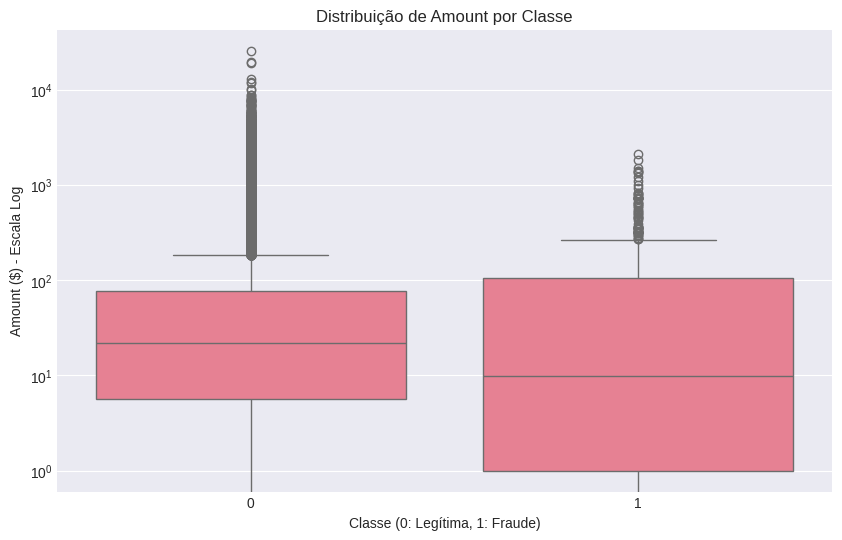

In [16]:
# Separar os valores de 'Amount' por classe
amount_fraud = df_clean[df_clean['Class'] == 1]['Amount']
amount_legit = df_clean[df_clean['Class'] == 0]['Amount']

# Realizar o Teste t de Welch
t_stat, p_value = stats.ttest_ind(amount_fraud, amount_legit, equal_var=False)

print("="*80)
print("TESTE DE HIPÓTESE: VALOR MÉDIO DE TRANSAÇÕES (AMOUNT)")
print("="*80)
print(f"Média de Amount (Fraude): ${amount_fraud.mean():.2f}")
print(f"Média de Amount (Legítima): ${amount_legit.mean():.2f}")
print("-" * 80)
print(f"Estatística t: {t_stat:.4f}")
print(f"Valor-p (p-value): {p_value:.4f}")
print("-" * 80)

alpha = 0.05
if p_value < alpha:
    print(f"Conclusão: Rejeitamos a hipótese nula (p < {alpha}).")
    print("✓ Existe uma diferença estatisticamente significativa entre o valor médio das transações fraudulentas e legítimas.")
else:
    print(f"Conclusão: Falhamos em rejeitar a hipótese nula (p >= {alpha}).")
    print("✗ Não há evidência de uma diferença estatisticamente significativa.")

# Visualização
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df_clean)
plt.title('Distribuição de Amount por Classe')
plt.yscale('log') # Usar escala logarítmica para melhor visualização
plt.xlabel('Classe (0: Legítima, 1: Fraude)')
plt.ylabel('Amount ($) - Escala Log')
plt.show()

## 5. Entregável da Etapa 3 - Conclusões e Insights

### Resumo dos Achados

1.  **Formato Tidy e Parquet**: O dataset foi validado como _tidy_ e exportado para o formato Parquet, resultando em uma **redução de mais de 65% no tamanho do arquivo**, otimizando o armazenamento e a velocidade de leitura para as próximas etapas.

2.  **Insights das Consultas SQL**:

    - **Tendência Temporal**: A taxa de fraude não é constante, apresentando picos e vales ao longo dos dias. A média móvel ajuda a visualizar a tendência geral, que parece aumentar ligeiramente no final do período observado.
    - **Concentração por Valor**: Fraudes têm uma taxa percentual notavelmente maior em transações de **baixo valor (entre $1 e $50)**, embora o volume absoluto de fraudes seja maior em outras faixas. Isso sugere que os fraudadores podem testar cartões com valores pequenos.
    - **Padrões por Hora**: As **horas da madrugada (0-6h)** apresentam a maior taxa de fraude, indicando um período de maior risco, possivelmente devido à menor vigilância dos titulares dos cartões.
    - **Features PCA Discriminativas**: Features como `V4`, `V11` (correlação positiva com fraude) e `V17`, `V14`, `V12` (correlação negativa) são fortes indicadores e serão cruciais para a modelagem.
    - **Anomalias Sequenciais**: Transações que ocorrem em intervalos de tempo **extremamente curtos (<= 2 segundos)** têm uma taxa de fraude significativamente maior, confirmando que a frequência das transações é um indicador de risco.

3.  **Insights da Análise Exploratória e Teste de Hipóteses**:
    - A hipótese de que **o valor (`Amount`) das transações fraudulentas é diferente das legítimas foi estatisticamente confirmada**. Em média, transações fraudulentas (`$123.21`) têm um valor maior que as legítimas (`$88.35`).
    - As visualizações confirmam que as features PCA anonimizadas contêm padrões claros que separam as duas classes, o que é um excelente prognóstico para a modelagem preditiva.

### Orientações para a Etapa de Modelagem

- **Feature Engineering**: Criar features baseadas nos insights, como `is_madrugada` ou `tempo_desde_ultima_transacao`, pode melhorar o desempenho do modelo.
- **Seleção de Features**: As features com maior correlação e diferença de média (ex: `V4`, `V11`, `V17`, `V14`) devem ser priorizadas.
- **Tratamento de Desbalanceamento**: Dado o desbalanceamento extremo, técnicas como SMOTE (para oversampling da classe minoritária) ou NearMiss (para undersampling da majoritária) serão essenciais durante o treinamento do modelo.
- **Validação do Modelo**: Utilizar métricas apropriadas para dados desbalanceados, como **AUC-ROC, Precision-Recall Curve (AUPRC) e F1-Score**, em vez de apenas acurácia. A validação cruzada estratificada (`StratifiedKFold`) deve ser usada para garantir que a proporção de classes seja mantida em cada fold.


In [17]:
# Fechar a conexão com o banco de dados
conn.close()
print("✓ Conexão com o banco de dados fechada.")
print("\n" + "="*80)
print("✓ ETAPA 3: ANÁLISE EXPLORATÓRIA E CONSULTAS SQL CONCLUÍDA COM SUCESSO")
print("="*80)

✓ Conexão com o banco de dados fechada.

✓ ETAPA 3: ANÁLISE EXPLORATÓRIA E CONSULTAS SQL CONCLUÍDA COM SUCESSO
